<br/>

<div align="center">
<span style="font-size: 2.5em;">S1-S2 Detector-Space Visualization</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Explore event clouds, grids, and iso-energy contours in XENON-like observables</span>
</div>

In [1]:
import os
desired_root_name = "xenon-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

In [2]:
# ---------------------------------------------------------------------
# Load in dataset
# ---------------------------------------------------------------------

n = 300000
halo = "shm"
datatag = "low"

PT_FILE = "data/datasets/xenon/s1s2/pt/" + f"s1s2_n{n}_{halo}.pt" 
data = torch.load(PT_FILE, weights_only=False)
print(data.keys())

# Extract data
theta_list = data["theta"]      # Parameters (m_chi, c_p)
energies_list = data["events"]  # Raw event energies
cs1cs2_list = data["cs1cs2"]    # S1 and S2 signals
xyz_list = data["xyz"]          # x,y,z positions

dict_keys(['theta', 'features', 'events', 'logcp_range', 'logm_range', 'n_train', 'top_k', 'halo_option', 'shmpp_file', 'mc_config', 'cs1cs2', 'xyz'])


## 1. Clean NaN values

Remove NaNs from cS1/cS2 and position arrays before analysis. NaNs typically arise from detector thresholds and acceptance cuts.

In [3]:
from utils.processing import clean_nan_events

# ---- Apply cleaning ----
energies_list, cs1cs2_list, xyz_list = clean_nan_events(energies_list, cs1cs2_list, xyz_list)

## 2. cS1/cS2 range diagnostics

Compute min/max values across all non-empty spectra to set plot limits and confirm expected scales.

In [4]:
# Concatenate all spectra and remove NaNs
cs1cs2_all = np.vstack([s for s in cs1cs2_list if s is not None and len(s) > 0])
cs1cs2_all = cs1cs2_all[np.isfinite(cs1cs2_all).all(axis=1)]

print(f'\nSpectra considered: {len([s for s in cs1cs2_list if s is not None and len(s) > 0])}')
print(f'Max cS1: {cs1cs2_all[:, 0].max():.2f}')
print(f'Max cS2: {cs1cs2_all[:, 1].max():.2f}')
print(f'Min cS1: {cs1cs2_all[:, 0].min():.2f}')
print(f'Min cS2: {cs1cs2_all[:, 1].min():.2f}')


Spectra considered: 120040
Max cS1: 244.70
Max cS2: 3896.80
Min cS1: 0.40
Min cS2: 89.24


## 3. Single-spectrum scatter

Visualize one spectrum in S1-S2 space, colored by recoil energy.

In [5]:
def plot_s1s2_spectrum(idx):
    """
    Plot the cS1–cS2 scatter for spectrum idx,
    with points color-coded by recoil energy.
    """
    spectrum = cs1cs2_list[idx]

    if spectrum is None or len(spectrum) == 0:
        print(f"Spectrum {idx} is empty.")
        return

    cs1 = spectrum[:, 0]
    cs2 = spectrum[:, 1]
    energies = energies_list[idx]   

    logm, logc = theta_list[idx]

    plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        cs1, cs2,
        c=energies,         
        cmap="plasma",     
        s=12,
        norm=plt.Normalize(1, 80)  # energy range in keV
    )

    # Add colorbar labeled in keV 
    cbar = plt.colorbar(sc) 
    cbar.set_label("Recoil energy [keV]", fontsize=12)

    # X axis
    plt.xlim(0, 100)
    plt.xticks(np.arange(0, 101, 20))

    # Y axis (log scale)
    plt.yscale("log")
    plt.ylim(10**2.1, 10**4.1)

    plt.xlabel("cS1 [PE]")
    plt.ylabel("cS2 [PE]")
    plt.title(f"Spectrum {idx}    logm={logm:.1f}, logc={logc:.2f}")
    plt.grid(True, ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


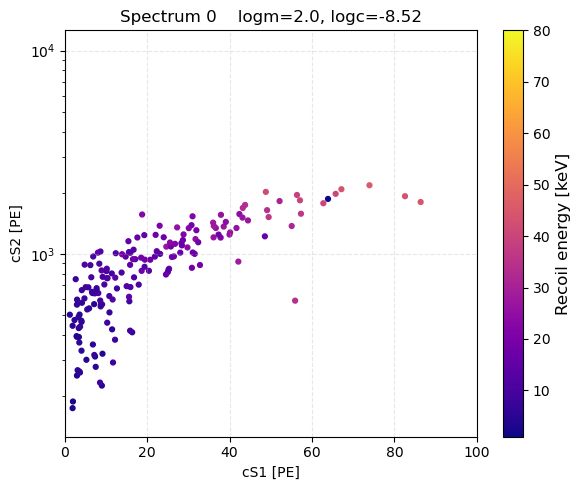

In [6]:
for i in range(1):
    plot_s1s2_spectrum(i)

## 4. Grid of spectra over parameter space

Plot a grid of S1-S2 scatters for spectra closest to a regular (log m, log c) grid.

In [7]:
def plot_s1s2_grid(
    cs1cs2_list,
    theta_list,
    logm_range,
    logcp_range,
    grid_dim=6,
    ylim=(10**2.1, 10**4.1),
    xlim=(0,100),
):
    """
    Plot a grid of real S1–S2 scatter plots from the dataset,
    choosing spectra whose (log m, log c) are closest to a regular grid.
    """

    # --- Only central values ---
    logm_values = np.linspace(logm_range[0], logm_range[1], grid_dim + 2)[1:-1]
    logcp_values = np.linspace(logcp_range[0], logcp_range[1], grid_dim + 2)[1:-1]
    
    # --- Include edges ---
    #logm_values = np.linspace(logm_range[0], logm_range[1], grid_dim )
    #logcp_values = np.linspace(logcp_range[0], logcp_range[1], grid_dim )

    target_pairs = [(lm, lc) for lc in logcp_values for lm in logm_values]

    theta_arr = np.asarray(theta_list)  # shape (N, 2)
    fig, axes = plt.subplots(
        grid_dim, grid_dim,
        figsize=(2.3 * grid_dim, 2.3 * grid_dim),
        sharex=True, sharey=True
    )

    axes = axes.reshape(grid_dim, grid_dim)

    for i, (logm_t, logc_t) in enumerate(target_pairs):
        r = i // grid_dim
        c = i % grid_dim
        ax = axes[r, c]

        # ---------------------------------------------
        # Find nearest spectrum
        # ---------------------------------------------
        dist = (theta_arr[:,0] - logm_t)**2 + (theta_arr[:,1] - logc_t)**2
        idx = np.argmin(dist)

        spectrum = cs1cs2_list[idx]

        arr = np.asarray(spectrum)
        cs1 = arr[:,0]
        cs2 = arr[:,1]

        # ---------------------------------------------
        # Plot scatter
        # ---------------------------------------------
        ax.scatter(cs1, cs2, s=5)

        # Axes formatting
        ax.set_xscale("linear")
        ax.set_xlim(*xlim)
        ax.set_xticks(np.arange(xlim[0], xlim[1]+1, 20))

        ax.set_yscale("log")
        ax.set_ylim(*ylim)

        ax.grid(True, ls="--", alpha=0.3)

        # Title: nearest actual parameters
        logm_real, logc_real = theta_arr[idx]
        ax.set_title(fr"$\log m={logm_real:.2f},\;\log c={logc_real:.2f}$",
                     fontsize=7)

    # Labels on outer edge only
    for ax in axes[-1,:]:
        ax.set_xlabel("cS1 [PE]")
    for ax in axes[:,0]:
        ax.set_ylabel("cS2 [PE]")

    plt.tight_layout()
    plt.show()

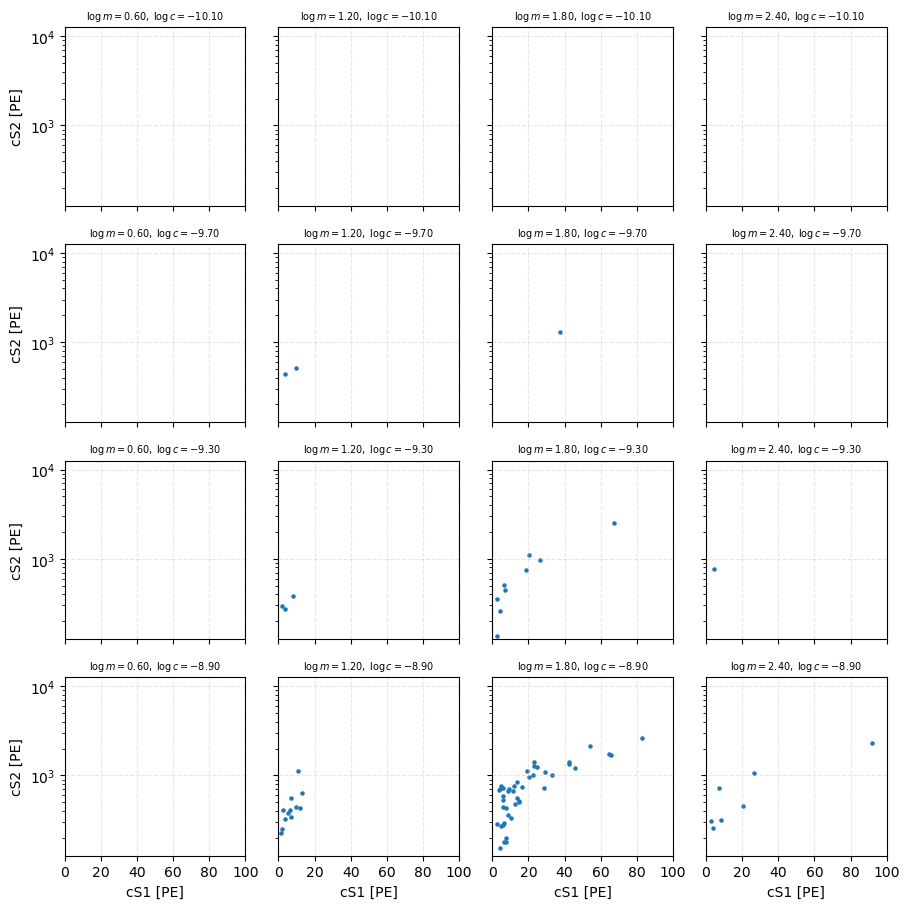

In [8]:
plot_s1s2_grid(
    cs1cs2_list,
    theta_list,
    logm_range=(0, 3),   
    logcp_range=(-10.5, -8.5),
    grid_dim=4
)

New version

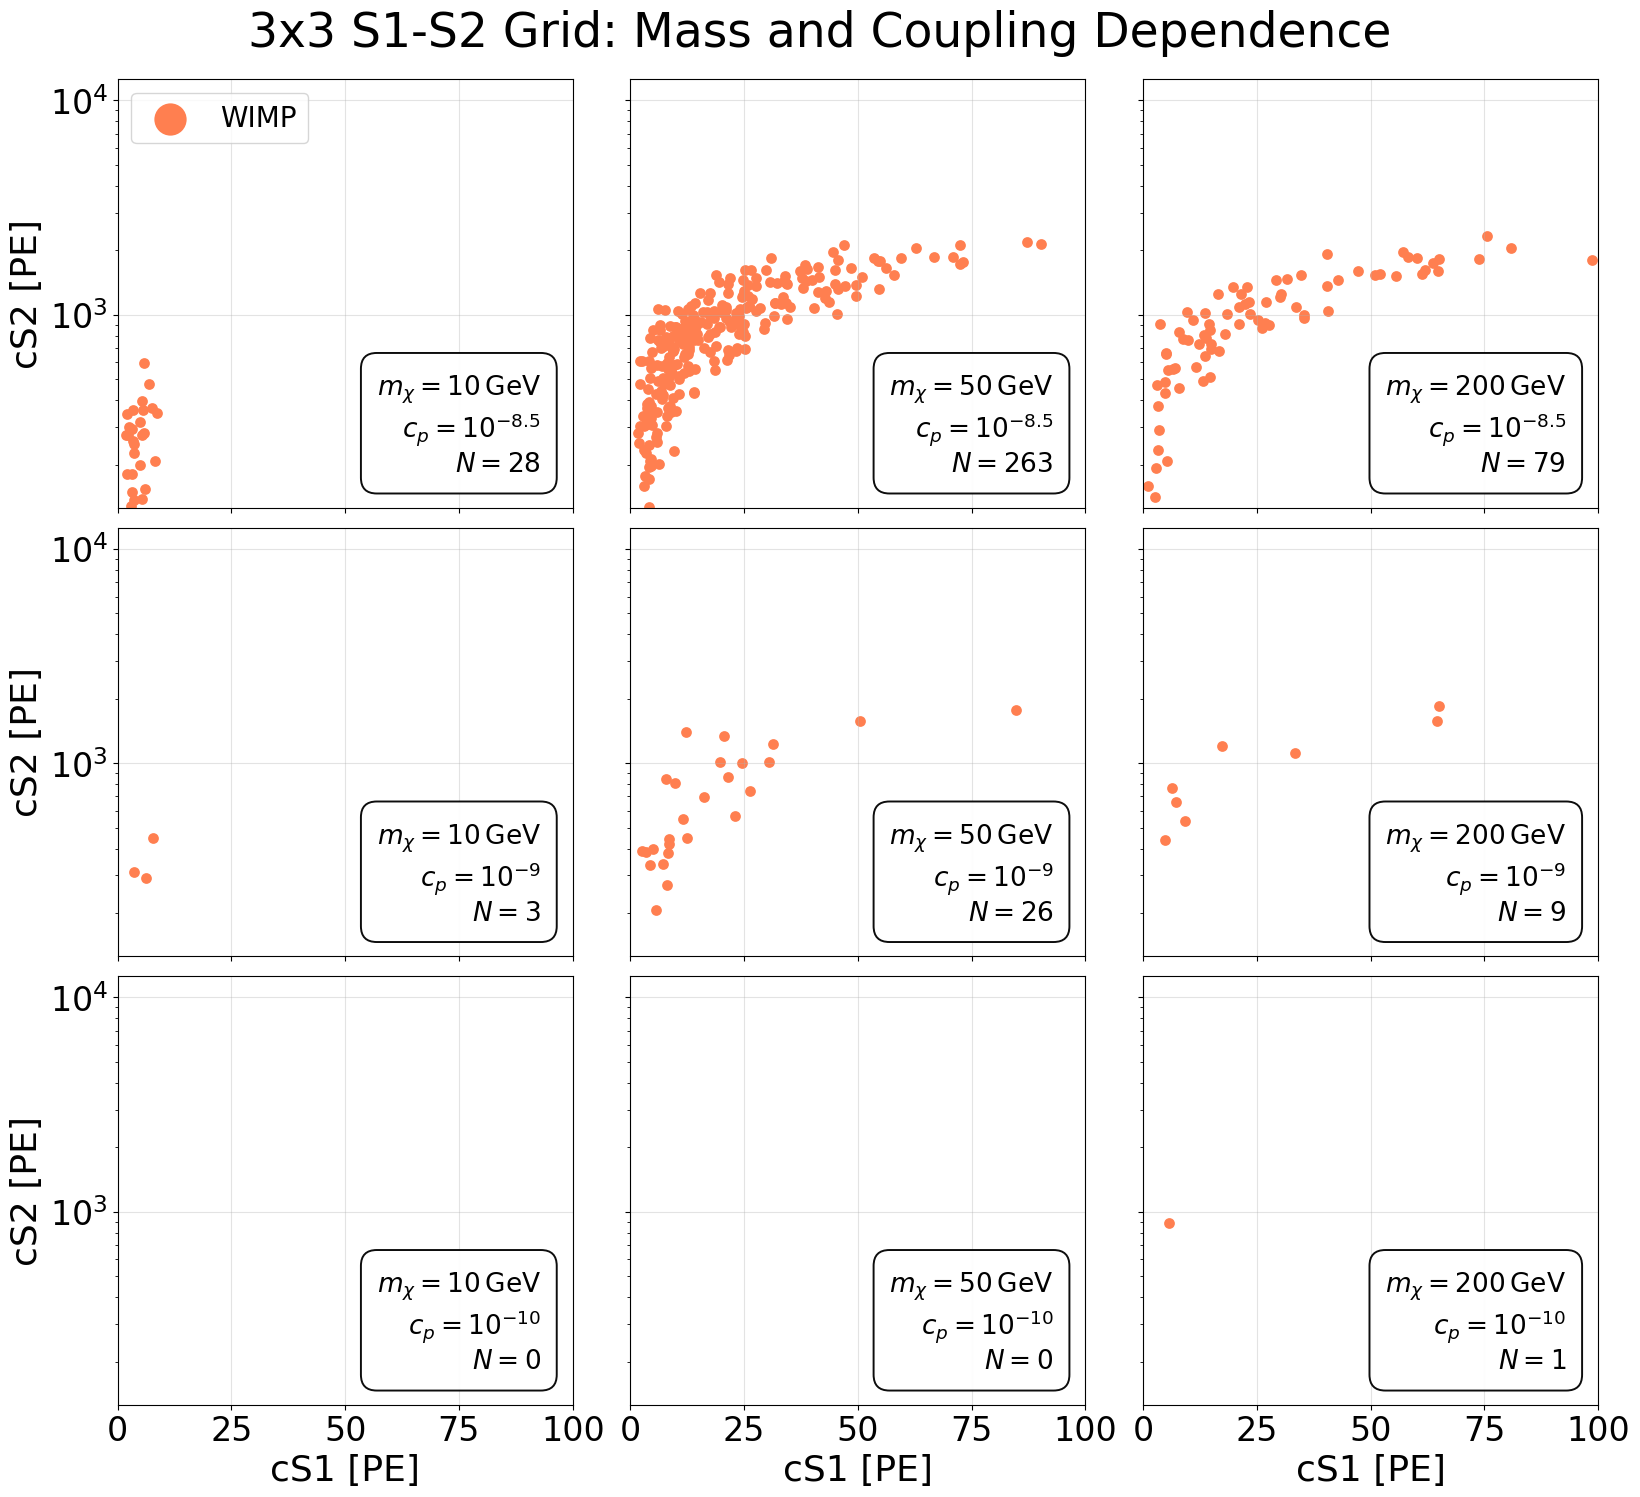

In [9]:
# =============================
# 3x3 GRID: S1-S2 SCATTER PLOTS
# =============================

grid_dim = 3
logms   = np.log10(np.array([10, 50, 200], dtype=float))
logcps  = np.array([-8.5, -9.0, -10.0], dtype=float)

if len(logms) != grid_dim or len(logcps) != grid_dim:
    raise ValueError("grid_dim must match the number of mass and coupling entries")

masses_grid    = np.rint(10**logms).astype(int).tolist()
couplings_grid = (10**logcps).tolist()

theta_arr = np.asarray(theta_list)  # shape (N, 2)

def cp_power_label(logcp):
    if np.isclose(logcp, round(logcp)):
        exp_str = f"{int(round(logcp))}"
    else:
        exp_str = f"{logcp:.1f}"
    return rf"$c_p = 10^{{{exp_str}}}$"

def format_nevents(nevents):
    if np.isclose(nevents, round(nevents)):
        return str(int(round(nevents)))
    return f"{nevents:.2f}"

# --- Find nearest spectrum for each grid point ---
all_spectra_s1s2 = {}
for r in range(grid_dim):
    for c in range(grid_dim):
        logm_t = logms[c]
        logc_t = logcps[r]
        dist   = (theta_arr[:, 0] - logm_t)**2 + (theta_arr[:, 1] - logc_t)**2
        idx    = int(np.argmin(dist))
        spectrum = cs1cs2_list[idx]
        arr      = np.asarray(spectrum)
        # remove non-finite rows
        arr = arr[np.isfinite(arr).all(axis=1)]
        nevents  = len(arr)
        all_spectra_s1s2[(r, c)] = (arr, nevents, theta_arr[idx])

# --- Plot ---
fig, axes = plt.subplots(
    grid_dim, grid_dim,
    figsize=(5.5 * grid_dim, 5.0 * grid_dim),
    sharex=True, sharey=True,
)
axes = np.array(axes).reshape(grid_dim, grid_dim)

for r in range(grid_dim):
    for c in range(grid_dim):
        ax = axes[r, c]
        arr, nevents, theta_real = all_spectra_s1s2[(r, c)]
        mchi = int(round(10**logms[c]))

        if len(arr) > 0:
            ax.scatter(
                arr[:, 0], arr[:, 1],
                s=60,
                color="#FF7F50", # #4067B1 for ER background (from XENONnT paper)
                alpha=1.0,
                linewidths=0,
                label="WIMP",
            )

        # Axes
        ax.set_xlim(0, 100)
        ax.set_yscale("log")
        ax.set_ylim(10**2.1, 10**4.1)
        ax.grid(alpha=0.35, linewidth=0.8)
        ax.tick_params(axis="both", labelsize=24)

        if r == grid_dim - 1:
            ax.set_xlabel("cS1 [PE]", fontsize=26)
        if c == 0:
            ax.set_ylabel("cS2 [PE]", fontsize=26)

        # Legend only in first panel
        if r == 0 and c == 0:
            ax.legend(fontsize=20, loc="upper left", markerscale=3)

        # Boxed annotation
        logm_real, logc_real = theta_real
        n_label   = format_nevents(nevents)
        info_text = (
            rf"$m_\chi = {mchi}\,\mathrm{{GeV}}$" + "\n" +
            cp_power_label(logcps[r]) + "\n" +
            rf"$N = {n_label}$"
        )
        ax.text(
            0.93, 0.07, info_text,
            transform=ax.transAxes,
            va="bottom", ha="right",
            fontsize=19,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="white",
                edgecolor="black",
                linewidth=1.4,
                alpha=0.95,
            )
        )

fig.suptitle(
    f"{grid_dim}x{grid_dim} S1-S2 Grid: Mass and Coupling Dependence",
    fontsize=34, y=0.995
)
plt.tight_layout()

#pdf_path = "figures/..."
#fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
#print(f"Figure saved to {pdf_path}")
plt.show()

## 5. XENON1T-style plots (I)

Reproduce cS1 vs cS2 and R^2 vs cS2 views for a single spectrum.

In [10]:
def plot_s1s2_and_r2(idx):
    """
    Left: cS1 vs cS2 (scatter)
    Right: R^2 vs cS2 with a secondary x-axis showing R
    Coordinates in xyz_list are assumed to be in mm.
    """

    cs1cs2 = cs1cs2_list[idx]
    xyz = xyz_list[idx]

    if cs1cs2 is None or len(cs1cs2) == 0:
        print(f"Spectrum {idx} is empty.")
        return

    cs1 = cs1cs2[:, 0]
    cs2 = cs1cs2[:, 1]

    x_mm, y_mm = xyz[:, 0], xyz[:, 1]

    # --- Convert mm → cm ---
    x = x_mm / 10.0
    y = y_mm / 10.0

    # --- Compute radius squared ---
    R2 = x**2 + y**2          # cm^2

    # --- Extract parameters ---
    logm, logc = theta_list[idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # =========================================================
    # LEFT PANEL (cS1 vs cS2 scatter)
    # =========================================================
    ax = axes[0]
    ax.scatter(cs1, cs2, s=10)
    ax.set_xlim(0, 150)
    ax.set_xticks(np.arange(0, 151, 25))

    ax.set_yscale("log")
    y_ticks = [200, 400, 1000, 2000, 4000, 8000]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(t) for t in y_ticks])
    ax.set_ylim(80, 8000)

    ax.set_xlabel("cS1 [PE]")
    ax.set_ylabel("cS2 [PE]")
    ax.set_title(f"Spectrum {idx} \n logm={logm:.1f}, logc={logc:.2f}")
    ax.grid(True, ls="--", alpha=0.3)

    # =========================================================
    # RIGHT PANEL (R^2 vs cS2)
    # =========================================================
    ax2 = axes[1]

    R2_safe = np.clip(R2, 1e-8, None) # Avoid np.sqrt(0)=0 in secondary axis
    R2_min, R2_max = R2_safe.min(), R2_safe.max()
    if R2_min == R2_max:
        # Add a small buffer around the single value
        delta = R2_min * 0.1 if R2_min > 0 else 1.0
        R2_min -= delta
        R2_max += delta
    ax2.scatter(R2_safe, cs2, s=10)
    ax2.set_xlim(0, 4356)  # 66^2 = 4356 cm^2
    ax2.set_xlabel(r"$R^2 \; [\mathrm{cm}^2]$")
    ax2.set_xticks(np.arange(0, 4001, 1000))
    ax2.grid(True, ls="--", alpha=0.3)

    # Secondary x-axis: R
    secax = ax2.secondary_xaxis("top", functions=(np.sqrt, lambda R: R**2))
    secax.set_xlabel(r"$R \; [\mathrm{cm}]$")
    secax.set_xticks(np.arange(10, 61, 10))

    fig.tight_layout()
    plt.show()

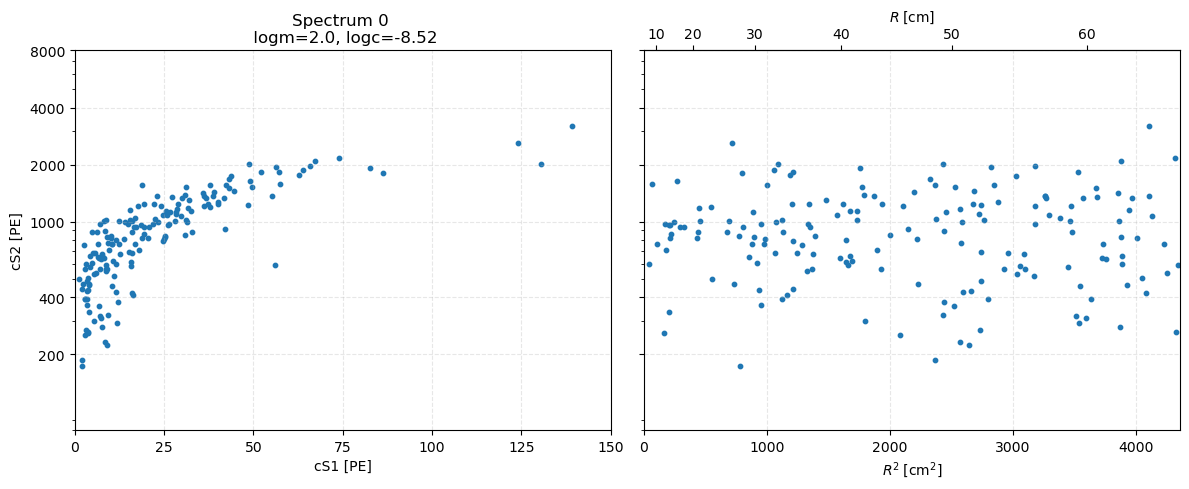

In [11]:
for i in range(1):
    plot_s1s2_and_r2(i)

## 6. XENON1T-style plots (II)

Top-down x-y view and side view (z vs R^2) to visualize event geometry.

In [12]:
def plot_xy_and_zr2(idx, cylinder_radius=66.0, cylinder_height=150.0):
    """
    Left: top-down view x vs y with detector edge (fixed radius 66 cm)
    Right: side view z vs R^2 with secondary axis showing R
    Coordinates are assumed to be in mm in xyz_list.
    """
    xyz = xyz_list[idx]

    
    if xyz is None or len(xyz) == 0:
        print(f"Spectrum {idx} is empty.")
        return

    # --- Convert mm → cm ---
    x = xyz[:, 0] / 10.0
    y = xyz[:, 1] / 10.0
    z = xyz[:, 2] / 10.0

    # --- Compute radius squared ---
    R2 = x**2 + y**2
    R = np.sqrt(R2)

     # --- Extract parameters ---
    logm, logc = theta_list[idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    # -----------------------------
    # LEFT: x vs y (top-down)
    # -----------------------------
    ax = axes[0]
    ax.scatter(x, y, s=10)

    # Circle showing detector edge
    theta = np.linspace(0, 2*np.pi, 200)
    circle_x = cylinder_radius * np.cos(theta)
    circle_y = cylinder_radius * np.sin(theta)
    ax.plot(circle_x, circle_y, color="darkorange", lw=1.5, label="Detector edge", alpha=0.6, ls="--")

    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(f"Spectrum {idx} \n logm={logm:.1f}, logc={logc:.2f}")
    ax.set_aspect('equal')
    ax.grid(True, ls="--", alpha=0.3)
    ax.legend(loc="upper right")

    # -----------------------------
    # RIGHT: z vs R^2
    # -----------------------------
    ax2 = axes[1]
    ax2.scatter(R2, z, s=10)

    ax2.set_xlabel(r"$R^2 \; [\mathrm{cm}^2]$")
    ax2.set_ylabel("z [cm]")
    ax2.set_xlim(0, cylinder_radius**2)
    ax2.set_ylim(-cylinder_height, 0)
    ax2.grid(True, ls="--", alpha=0.3)

    # Secondary x-axis: R
    secax = ax2.secondary_xaxis("top", functions=(np.sqrt, lambda R: R**2))
    secax.set_xlabel(r"$R \; [\mathrm{cm}]$")
    secax.set_xticks(np.arange(10, 61, 10))

    plt.tight_layout()
    plt.show()


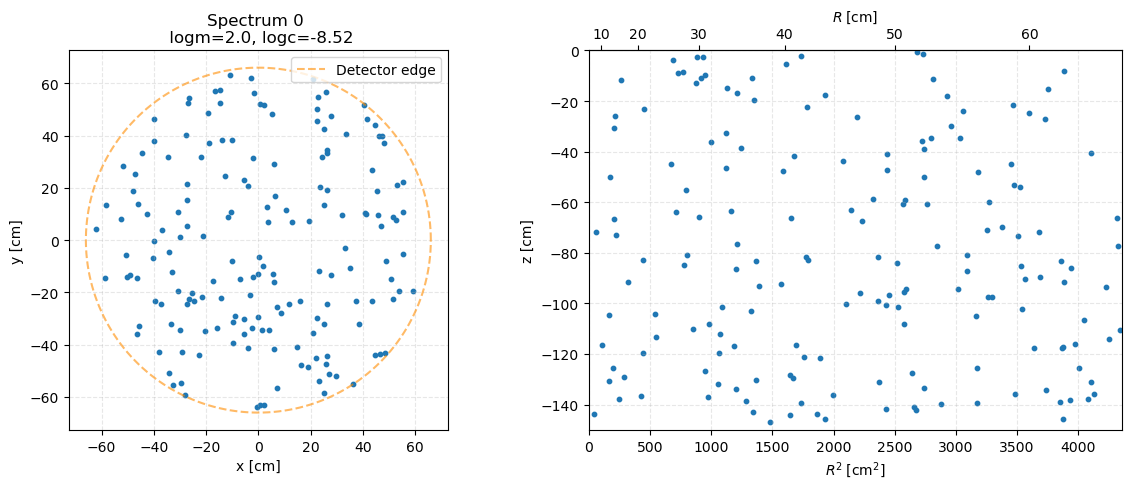

In [13]:
for i in range(1):
    plot_xy_and_zr2(i)

## 7. Iso-energy contours

Build cS1-cS2 contours for fixed recoil energies using g1 and g2 calibration.

### g1 and g2 for SR2 (v18)

Energy depositions in the TPC produce a light signal (S1) and a charge signal (S2). Using corrected signals:

$$ E = W \cdot (n_\mathrm{ph} + n_\mathrm{e}) = W \cdot \left( \frac{cS1}{g_1} + \frac{cS2}{g_2} \right) $$

$W = 13.7 \, \mathrm{eV}$ is the mean energy to produce a charge or light quantum. $g_1$ is the photon detection efficiency and $g_2$ is the charge amplification (yield factors).

### Doke method

To determine $g_1$ and $g_2$, use mono-energetic lines with known energies. After algebra, the relation becomes:

$$CY=-\frac{g_2}{g_1} LY + \frac{g_2}{W}$$

with charge yield $CY=\frac{cS2}{E}$ and light yield $LY=\frac{cS1}{E}$. If we obtain the mean positions in cS1 and cS2 for multiple sources, we can fit this line to extract $g_1$ and $g_2$.

Mono-energetic gamma lines appear as rotated 2D Gaussian peaks in cS1-cS2 space. The mean positions can be obtained from fits using:

$$f(x,y) = A \cdot \exp\left(-\frac{[(x-\mu_x)\cdot \cos \theta-(y-\mu_y)\cdot \sin \theta]^2}{2a^2}-\frac{[(x-\mu_x)\cdot \sin \theta+(y-\mu_y)\cdot \cos \theta]^2}{2b^2} \right).$$

This function can be extended with background components as needed.

### Results for SR2

$$g_1 = (0.1395 \pm 0.0012)\ \mathrm{PE}/\mathrm{ph}$$
$$g_2 = (13.97 \pm 0.047)\ \mathrm{PE}/\mathrm{e}$$

$$cS_2 = g_2 \frac{E}{W} - \frac{g_2}{g_1} cS_1$$

In [14]:
# === Yield parameters ===
W = 13.7e-3 # keV per quantum (on average)
g1 = 0.1395
g2 = 13.97


def cs2_from_energy(E_keV, cS1, W=W): return g2*(E_keV/W) - (g2/g1)*cS1

def Lindhard_factor(E_keV, k=0.110):
    """
    Compute Lindhard factor L(E) for nuclear recoils in xenon, i.e. the fraction of energy that goes into electrons and photons
    E_keV: recoil energy in keV
    Returns L(E) (dimensionless)
    See: A Global Analysis of Light and Charge Yields in Liquid Xenon (Lenardo et al. 2015)
    """
    Z = 54  # atomic number for xenon
    # k = 0.133 * (Z)**(2/3) * (A)**(-1/2) # original k formula from Lindhard et al. with A = 131.293 -> k = 0.166
    epsilon = 11.5 * E_keV * (Z)**(-7/3)
    g_epsilon = 3 * epsilon**0.15 + 0.7 * epsilon**0.6 + epsilon
    L = k * g_epsilon / (1 + k * g_epsilon)
    return L


NRs behave very differently compared to ERs:

- A large fraction of recoil energy is lost to heat/atomic motion (not to quanta)
- Ionization and scintillation yields are quenched
- Quanta follow Lindhard theory or XENON-specific parametrizations (NEST-based)

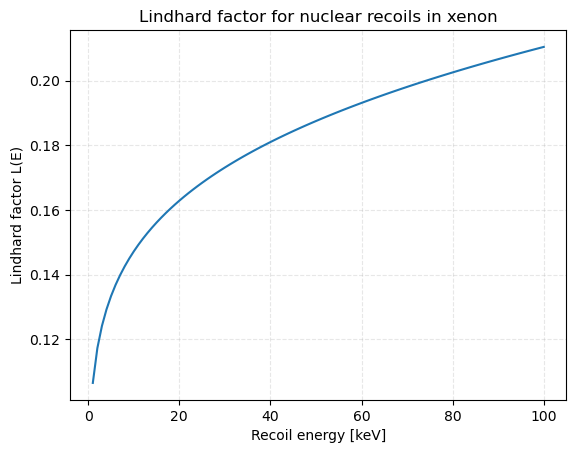

In [15]:
# === Plot Lindhard factor ===

ener = np.linspace(1, 100, 100)
lind = Lindhard_factor(ener, k=0.110)
plt.plot(ener, lind)
plt.xlabel("Recoil energy [keV]")
plt.ylabel("Lindhard factor L(E)")
plt.title("Lindhard factor for nuclear recoils in xenon")
plt.grid(True, ls="--", alpha=0.3)
plt.show()

In [16]:
def plot_s1s2_with_isoenergy(idx, recoil_type='nr'):
    """
    Scatter plot of cS1–cS2 with iso-energy contour lines.
    
    Parameters:
    -----------
    idx : int
        Index of the spectrum to plot
    recoil_type : str
        'nr' for nuclear recoils (default) or 'er' for electronic recoils
    """
    spectrum = cs1cs2_list[idx]
    energies = energies_list[idx]  # keV energies

    if spectrum is None or len(spectrum) == 0:
        return

    cs1 = spectrum[:, 0]
    cs2 = spectrum[:, 1]
    logm, logc = theta_list[idx]

    # ------------------------
    # Figure setup
    # ------------------------
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(cs1, cs2, c=energies, s=15, cmap="plasma", norm=plt.Normalize(1, 80))
    cbar = plt.colorbar(sc)
    cbar.set_label("Recoil energy [keV]")

    # ------------------------
    # Axes configuration (differs by recoil type)
    # ------------------------
    if recoil_type == 'er':
        ax.set_xlim(1, 10000)
        ax.set_xscale("log")
        ax.set_ylim(10, 200000)
        ax.set_yscale("log")
        
        # ISO-ENERGY LINES for ER
        cS1_line = np.linspace(0, 10000, 10000)
        iso_E = [5, 10, 25, 100]
        
        for E in iso_E:
            cS2_line = cs2_from_energy(E, cS1_line)
            ax.plot(cS1_line, cS2_line, color="gray", lw=1.0, alpha=0.7)
            ax.text(10, cs2_from_energy(E, 50) + 3000,
                    f" {E} keV",
                    fontsize=9, color="gray", va="center")
    else:  # nr
        ax.set_xlim(0, 100)
        ax.set_xticks(np.arange(0, 101, 20))
        ax.set_ylim(10**2.1, 10**4.1)
        ax.set_yscale("log")
        
        # ISO-ENERGY LINES for NR
        cS1_line = np.linspace(0, 100, 400)
        iso_E = [10, 20, 30, 40, 50, 60, 70]
        
        for E in iso_E:
            cS2_line = cs2_from_energy(E * Lindhard_factor(E, k=0.110), cS1_line)
            ax.plot(cS1_line, cS2_line, color="gray", lw=1.0, alpha=0.7)
        
        # Labels
        labels = iso_E[:5]
        x_positions = [16, 34, 54, 75, 97]
        y_pos = 130
        
        for x, E in zip(x_positions, labels):
            ax.text(x, y_pos, f"{E}", fontsize=9, color="gray",
                    ha="center", va="bottom")

    ax.set_xlabel("cS1 [PE]")
    ax.set_ylabel("cS2 [PE]")
    ax.set_title(f"Spectrum {idx}  (logm={logm:.1f}, logc={logc:.2f})")
    ax.grid(True, ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

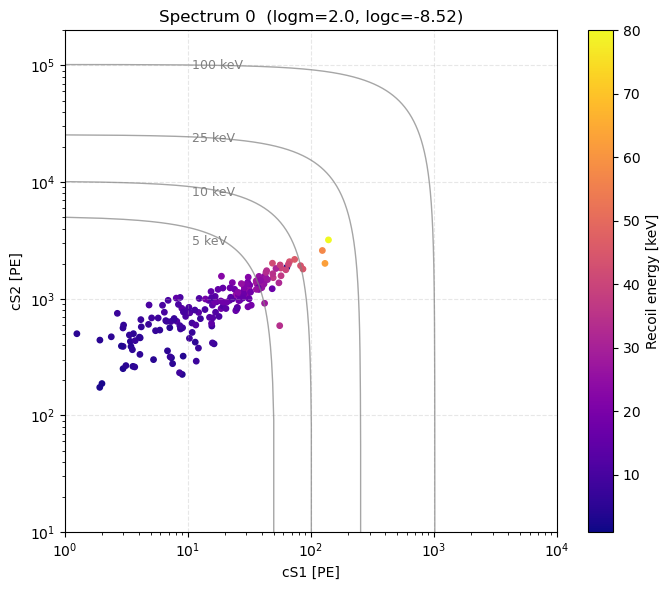

In [17]:
plot_s1s2_with_isoenergy(0, recoil_type='er')

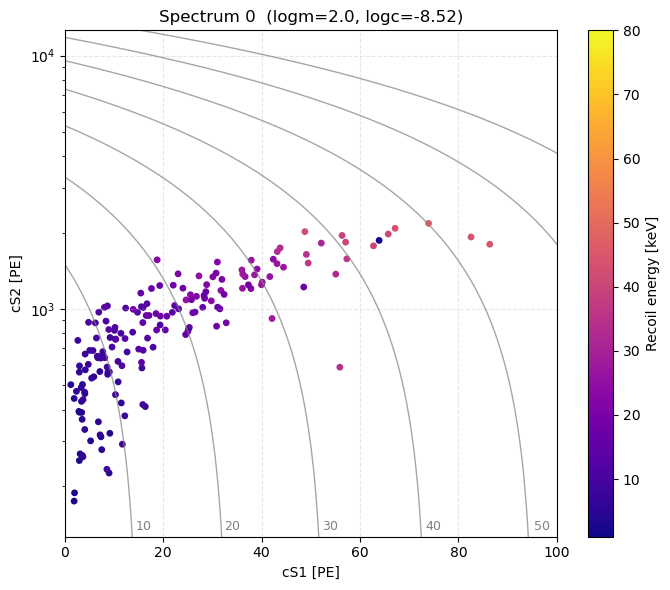

In [18]:
for i in range(1):
    plot_s1s2_with_isoenergy(i, recoil_type='nr')